# Fixed- and variable-order Mizuta MPF comparison

This notebook compares the same ideal MPF algorithm under three rigorous sizing proofs: Low 2019, the printed Mizuta Theorem-3 auxiliary-allocation implementation, and the refined Mizuta implementation that evaluates the Lemma-9/Lemma-10 BCH remainder directly. Experiment 1 fixes $J=3$. Experiment 2 resolves $J$ exactly once from the repository's even-order realization of Mizuta Theorem 6,

$$J=\max\!\left(2,\left\lceil\tfrac12\log\frac{Ng|t|}{\epsilon_{\rm alg}}\right\rceil\right),$$

and supplies the same resolved schedule and coefficients to all three estimators. No optimization over $J$ is performed.


In [1]:
%load_ext autoreload
%autoreload 2


In [2]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from IPython.display import display

root = Path.cwd().resolve()
if root.name == 'notebooks':
    root = root.parent
sys.path.insert(0, str(root / 'src'))

from hamiltonian_resources import (
    heisenberg_chain,
    multiproduct_coefficients,
    optimal_mpf_exponents,
    pauli_locality_parameters,
    resolve_mpf_branch_count,
    select_mpf_segments,
    transverse_field_ising,
)

METHODS = {
    'Low 2019': 'low2019-l1-ideal-rigorous',
    'Mizuta legacy Theorem 3': 'mizuta2026-theorem3-legacy-ideal-rigorous',
    'Mizuta refined': 'mizuta2026-commutator-ideal-rigorous',
}
MODELS = {
    'open TFIM (J=1, h=3)': lambda n: transverse_field_ising(
        n, coupling=1.0, field=3.0, periodic=False
    ),
    'open XXX (J=1, h_z=0)': lambda n: heisenberg_chain(
        n, coupling=1.0, field_z=0.0
    ),
}
SIZES = (4, 8, 16, 32, 50, 75, 100)
TARGETS = np.logspace(-1, -6, 11)
FIXED_J = 3
MARKERS = {
    'error': 'o', 'time_1': '^', 'time_2': 's', 'joint_p0': 'D',
    'commuting_exact': 'P', 'zero_time_exact': 'P', 'not-applicable': 'x',
}


## Auditable sweep helpers

The policy is resolved before estimator selection. Each row retains the physical schedule data and enough diagnostic provenance to distinguish a commutator-limited point, a BCH-limited point, a legacy first-condition failure, a locality fallback, and a refined-tail fallback.


In [3]:
def resolve_policy_point(hamiltonian, time, epsilon, policy):
    selection = resolve_mpf_branch_count(
        hamiltonian,
        time,
        epsilon,
        policy=policy,
        term_count=FIXED_J if policy == 'fixed' else None,
    )
    exponents = optimal_mpf_exponents(selection.term_count)
    coefficients = multiproduct_coefficients(selection.term_count)
    _, g = pauli_locality_parameters(hamiltonian)
    return selection, exponents, coefficients, g


def summarize(model, hamiltonian, time, epsilon, label, method, selection, exponents, coefficients, g, sweep_name):
    estimate = select_mpf_segments(
        hamiltonian,
        time,
        epsilon,
        selection.term_count,
        method=method,
        workers=4,
    )
    diagnostics = estimate.segment_diagnostics
    components = dict(estimate.bound_components)
    commutator = components.get('local_commutator_error')
    bch = components.get(
        'total_branchwise_bch_remainder',
        components.get('local_truncated_bch_error'),
    )
    if commutator is None or bch is None:
        dominance = 'not-applicable'
    elif commutator > bch:
        dominance = 'commutator'
    elif commutator < bch:
        dominance = 'BCH'
    else:
        dominance = 'tie'
    legacy_limit = components.get(
        'legacy_first_time_limit', components.get('first_time_limit')
    )
    legacy_pass = (
        None if legacy_limit is None else abs(time) / estimate.segments <= legacy_limit
    )
    exponent_sum = sum(exponents)
    return {
        'sweep': sweep_name,
        'policy': selection.policy,
        'model': model,
        'N': hamiltonian.num_qubits,
        'time': time,
        'epsilon': epsilon,
        'estimator': label,
        'method': method,
        'J': selection.term_count,
        'formal_order': selection.formal_order,
        'g': g,
        'sum_k': exponent_sum,
        'coefficient_l1': float(sum(abs(coefficients))),
        'segments': estimate.segments,
        'query_count': 3 * estimate.segments * exponent_sum,
        'bound': estimate.error,
        'p0': None if diagnostics is None else diagnostics.truncation_order_p0,
        'active_constraint': (
            'not-applicable'
            if diagnostics is None
            else '+'.join(diagnostics.active_constraints)
        ),
        'local_error_dominance': dominance,
        'legacy_first_pass': legacy_pass,
        'exact_commutator_cutoff': estimate.max_exact_nested_commutator_order,
        'locality_fallback': (
            False if diagnostics is None else diagnostics.used_locality_fallback
        ),
        'refined_tail_fallback': (
            'not-applicable'
            if diagnostics is None
            else diagnostics.refined_tail_fallback_status
        ),
    }


def sweep(policy, *, sizes=SIZES, targets=TARGETS):
    rows = []
    for model, constructor in MODELS.items():
        for size in sizes:
            hamiltonian = constructor(size)
            selection, exponents, coefficients, g = resolve_policy_point(
                hamiltonian, float(size), 1e-3, policy
            )
            for label, method in METHODS.items():
                rows.append(summarize(
                    model, hamiltonian, float(size), 1e-3, label, method,
                    selection, exponents, coefficients, g, 'system-size',
                ))
        hamiltonian = constructor(50)
        for epsilon in targets:
            selection, exponents, coefficients, g = resolve_policy_point(
                hamiltonian, 50.0, float(epsilon), policy
            )
            for label, method in METHODS.items():
                rows.append(summarize(
                    model, hamiltonian, 50.0, float(epsilon), label, method,
                    selection, exponents, coefficients, g, 'target-error',
                ))
    return pd.DataFrame(rows)


def constraint_marker(value):
    return MARKERS.get(str(value).split('+')[0], 'x')


def plot_segments(frame, *, sweep_name, title):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)
    x_column = 'N' if sweep_name == 'system-size' else 'epsilon'
    selector = frame['sweep'].eq(sweep_name)
    for axis, model in zip(axes, MODELS, strict=True):
        subset = frame[selector & frame['model'].eq(model)]
        for label in METHODS:
            values = subset[subset['estimator'].eq(label)].sort_values(x_column)
            line, = axis.loglog(values[x_column], values['segments'], label=label)
            for _, row in values.iterrows():
                axis.scatter(
                    row[x_column], row['segments'], color=line.get_color(),
                    marker=constraint_marker(row['active_constraint']), s=45,
                )
                if row['policy'] != 'fixed':
                    axis.annotate(
                        f"J={int(row['J'])}",
                        (row[x_column], row['segments']),
                        xytext=(3, 4), textcoords='offset points', fontsize=7,
                    )
        if sweep_name == 'target-error':
            axis.invert_xaxis()
        axis.set(
            title=model,
            xlabel='system size N' if sweep_name == 'system-size' else 'target error epsilon',
            ylabel='segments r',
        )
        axis.grid(True, which='both', alpha=0.25)
    axes[0].legend()
    fig.suptitle(title)
    plt.show()


## Experiment 1 — fixed $J=3$ (formal order 6)

The seven-size and eleven-target sweeps below compare only proof-induced sizing changes. Every estimator receives exactly $J=3$, the exponent schedule $(1,2,4)$, and the same MPF coefficients.


,model,N,estimator,J,formal_order,g,sum_k,coefficient_l1,segments,p0,active_constraint,local_error_dominance,legacy_first_pass,locality_fallback,refined_tail_fallback,query_count
0,"open TFIM (J=1, h=3)",4,Low 2019,3,6,5.0,7,1.888889,123,NaN,error,not-applicable,None,None,None,2583
1,"open TFIM (J=1, h=3)",4,Mizuta legacy Theorem 3,3,6,5.0,7,1.888889,321369,25.0,time_1,BCH,True,None,None,6748749
2,"open TFIM (J=1, h=3)",4,Mizuta refined,3,6,5.0,7,1.888889,1180,6.0,error,commutator,False,False,not-used,24780
3,"open TFIM (J=1, h=3)",8,Low 2019,3,6,5.0,7,1.888889,633,NaN,error,not-applicable,None,None,None,13293
4,"open TFIM (J=1, h=3)",8,Mizuta legacy Theorem 3,3,6,5.0,7,1.888889,694157,27.0,time_1,BCH,True,None,None,14577297
5,"open TFIM (J=1, h=3)",8,Mizuta refined,3,6,5.0,7,1.888889,3395,6.0,error,commutator,False,False,not-used,71295
6,"open TFIM (J=1, h=3)",16,Low 2019,3,6,5.0,7,1.888889,3207,NaN,error,not-applicable,None,None,None,67347
7,"open TFIM (J=1, h=3)",16,Mizuta legacy Theorem 3,3,6,5.0,7,1.888889,1439732,28.0,time_1,BCH,True,None,None,30234372
8,"open TFIM (J=1, h=3)",16,Mizuta refined,3,6,5.0,7,1.888889,9555,6.0,error,commutator,False,False,not-used,200655
9,"open TFIM (J=1, h=3)",32,Low 2019,3,6,5.0,7,1.888889,16140,NaN,error,not-applicable,None,None,None,338940


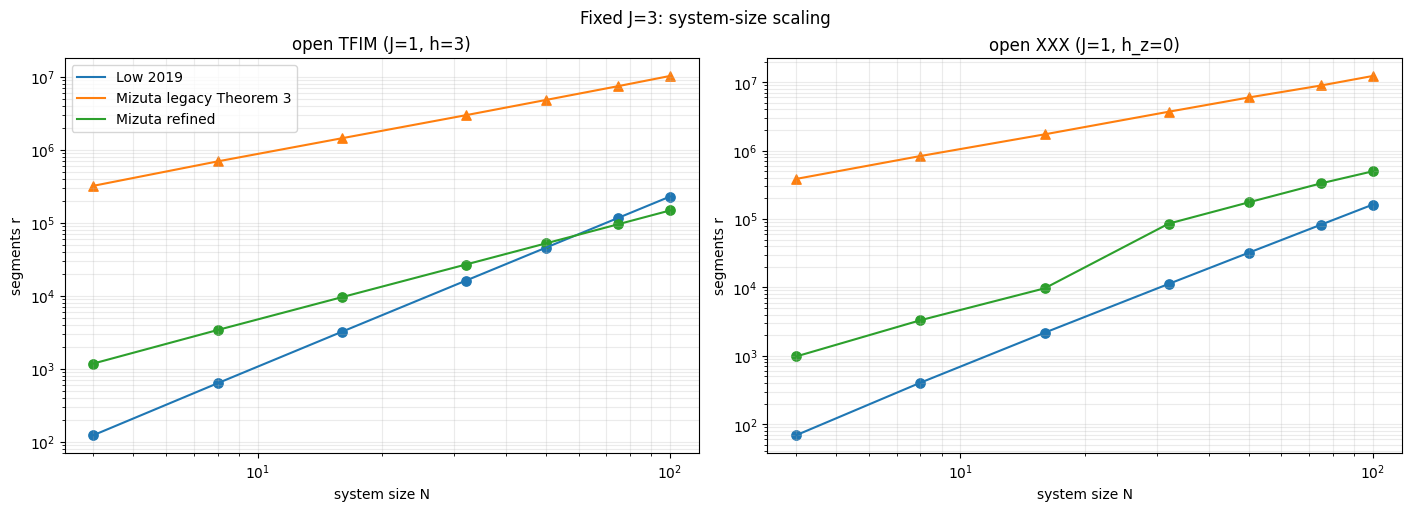

In [4]:
fixed = sweep('fixed')
fixed_sizes = fixed[fixed['sweep'].eq('system-size')].copy()
fixed_targets = fixed[fixed['sweep'].eq('target-error')].copy()

display(fixed_sizes[[
    'model', 'N', 'estimator', 'J', 'formal_order', 'g', 'sum_k',
    'coefficient_l1', 'segments', 'p0', 'active_constraint',
    'local_error_dominance', 'legacy_first_pass', 'locality_fallback',
    'refined_tail_fallback', 'query_count',
]])
plot_segments(fixed, sweep_name='system-size', title='Fixed J=3: system-size scaling')


,model,epsilon,estimator,J,formal_order,segments,p0,active_constraint,local_error_dominance,legacy_first_pass,locality_fallback,refined_tail_fallback,query_count
21,"open TFIM (J=1, h=3)",0.100000,Low 2019,3,6,22326,NaN,error,not-applicable,None,None,None,468846
22,"open TFIM (J=1, h=3)",0.100000,Mizuta legacy Theorem 3,3,6,4177792,26.0,time_1,BCH,True,None,None,87733632
23,"open TFIM (J=1, h=3)",0.100000,Mizuta refined,3,6,24599,6.0,error,commutator,False,False,not-used,516579
24,"open TFIM (J=1, h=3)",0.031623,Low 2019,3,6,26467,NaN,error,not-applicable,None,None,None,555807
25,"open TFIM (J=1, h=3)",0.031623,Mizuta legacy Theorem 3,3,6,4338476,27.0,time_1,BCH,True,None,None,91107996
...,...,...,...,...,...,...,...,...,...,...,...,...,...
103,"open XXX (J=1, h_z=0)",0.000003,Mizuta legacy Theorem 3,3,6,7134383,37.0,time_1,BCH,True,None,None,149822043
104,"open XXX (J=1, h_z=0)",0.000003,Mizuta refined,3,6,456913,6.0,error,commutator,False,True,not-used,9595173
105,"open XXX (J=1, h_z=0)",0.000001,Low 2019,3,6,98897,NaN,error,not-applicable,None,None,None,2076837
106,"open XXX (J=1, h_z=0)",0.000001,Mizuta legacy Theorem 3,3,6,7327204,38.0,time_1,BCH,True,None,None,153871284


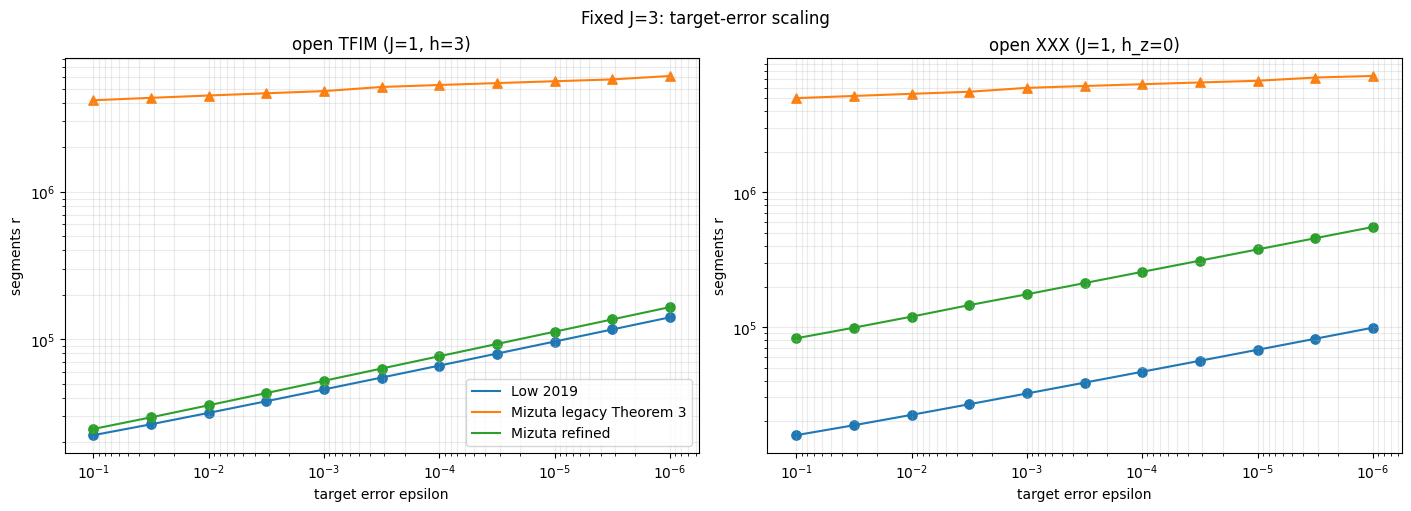

,model,estimator,small-epsilon fitted slope,formal-order prediction,absolute deviation
0,"open TFIM (J=1, h=3)",Low 2019,-0.163790,-0.166667,0.002876
1,"open TFIM (J=1, h=3)",Mizuta refined,-0.166662,-0.166667,0.000005
2,"open XXX (J=1, h_z=0)",Low 2019,-0.163646,-0.166667,0.003021
3,"open XXX (J=1, h_z=0)",Mizuta refined,-0.166663,-0.166667,0.000003


In [5]:
display(fixed_targets[[
    'model', 'epsilon', 'estimator', 'J', 'formal_order', 'segments', 'p0',
    'active_constraint', 'local_error_dominance', 'legacy_first_pass',
    'locality_fallback', 'refined_tail_fallback', 'query_count',
]])
plot_segments(fixed, sweep_name='target-error', title='Fixed J=3: target-error scaling')

slope_rows = []
for (model, estimator), values in fixed_targets[
    fixed_targets['estimator'].isin(['Low 2019', 'Mizuta refined'])
].groupby(['model', 'estimator']):
    values = values.sort_values('epsilon').head(5)
    slope = np.polyfit(np.log(values['epsilon']), np.log(values['segments']), 1)[0]
    slope_rows.append({
        'model': model,
        'estimator': estimator,
        'small-epsilon fitted slope': slope,
        'formal-order prediction': -1 / 6,
        'absolute deviation': abs(slope + 1 / 6),
    })
fixed_slopes = pd.DataFrame(slope_rows)
display(fixed_slopes)


## Experiment 2 — deterministic Mizuta Theorem-6 policy

For each $(H,t,\epsilon)$ point, the resolver is called once. Its selected $J$, exponents, and coefficients are then reused by Low, legacy Mizuta, and refined Mizuta. The table's query count is the repository's exact logical controlled-$S_2$ count, $3r\sum_j k_j$.


,model,N,estimator,J,formal_order,g,sum_k,coefficient_l1,segments,p0,active_constraint,local_error_dominance,legacy_first_pass,locality_fallback,refined_tail_fallback,query_count
0,"open TFIM (J=1, h=3)",4,Low 2019,6,12,5.0,32,1.972128,31,NaN,error,not-applicable,None,None,None,2976
1,"open TFIM (J=1, h=3)",4,Mizuta legacy Theorem 3,6,12,5.0,32,1.972128,347079,27.0,time_1,BCH,True,None,None,33319584
2,"open TFIM (J=1, h=3)",4,Mizuta refined,6,12,5.0,32,1.972128,434,12.0,error,commutator,False,False,not-used,41664
3,"open TFIM (J=1, h=3)",8,Low 2019,7,14,5.0,46,1.965530,107,NaN,error,not-applicable,None,None,None,14766
4,"open TFIM (J=1, h=3)",8,Mizuta legacy Theorem 3,7,14,5.0,46,1.965530,745576,29.0,time_1,BCH,True,None,None,102889488
5,"open TFIM (J=1, h=3)",8,Mizuta refined,7,14,5.0,46,1.965530,947,14.0,error,commutator,False,False,not-used,130686
6,"open TFIM (J=1, h=3)",16,Low 2019,8,16,5.0,61,1.978985,380,NaN,error,not-applicable,None,None,None,69540
7,"open TFIM (J=1, h=3)",16,Mizuta legacy Theorem 3,8,16,5.0,61,1.978985,1542570,30.0,time_1,BCH,True,None,None,282290310
8,"open TFIM (J=1, h=3)",16,Mizuta refined,8,16,5.0,61,1.978985,2034,16.0,error,commutator,False,False,not-used,372222
9,"open TFIM (J=1, h=3)",32,Low 2019,8,16,5.0,61,1.978985,1648,NaN,error,not-applicable,None,None,None,301584


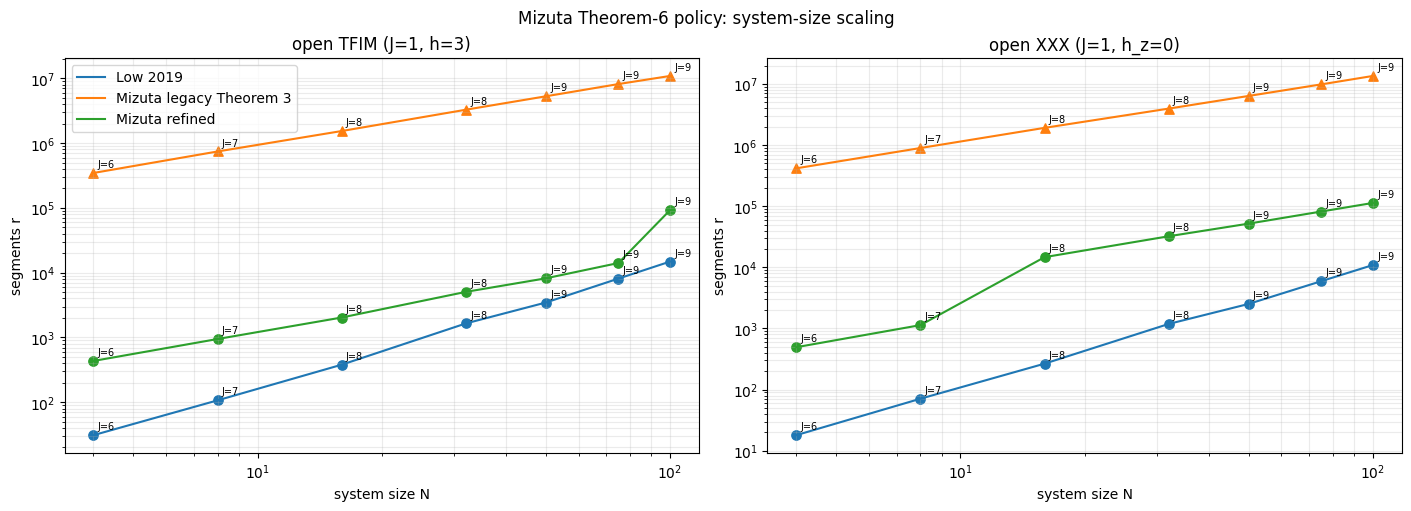

In [6]:
dynamic = sweep('mizuta2026-theorem6')
dynamic_sizes = dynamic[dynamic['sweep'].eq('system-size')].copy()
dynamic_targets = dynamic[dynamic['sweep'].eq('target-error')].copy()

display(dynamic_sizes[[
    'model', 'N', 'estimator', 'J', 'formal_order', 'g', 'sum_k',
    'coefficient_l1', 'segments', 'p0', 'active_constraint',
    'local_error_dominance', 'legacy_first_pass', 'locality_fallback',
    'refined_tail_fallback', 'query_count',
]])
plot_segments(
    dynamic, sweep_name='system-size',
    title='Mizuta Theorem-6 policy: system-size scaling',
)


,model,epsilon,estimator,J,formal_order,g,sum_k,coefficient_l1,segments,p0,active_constraint,local_error_dominance,legacy_first_pass,locality_fallback,refined_tail_fallback,query_count
21,"open TFIM (J=1, h=3)",0.100000,Low 2019,6,12,5.0,32,1.972128,5245,NaN,error,not-applicable,None,None,None,503520
22,"open TFIM (J=1, h=3)",0.100000,Mizuta legacy Theorem 3,6,12,5.0,32,1.972128,4338476,27.0,time_1,BCH,True,None,None,416493696
23,"open TFIM (J=1, h=3)",0.100000,Mizuta refined,6,12,5.0,32,1.972128,8984,12.0,error,commutator,False,False,not-used,862464
24,"open TFIM (J=1, h=3)",0.031623,Low 2019,7,14,5.0,46,1.965530,4359,NaN,error,not-applicable,None,None,None,601542
25,"open TFIM (J=1, h=3)",0.031623,Mizuta legacy Theorem 3,7,14,5.0,46,1.965530,4659845,29.0,time_1,BCH,True,None,None,643058610
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
103,"open XXX (J=1, h_z=0)",0.000003,Mizuta legacy Theorem 3,12,24,6.0,152,1.991346,7712847,40.0,time_1,BCH,True,None,None,3517058232
104,"open XXX (J=1, h_z=0)",0.000003,Mizuta refined,12,24,6.0,152,1.991346,65449,24.0,error,commutator,False,True,not-used,29844744
105,"open XXX (J=1, h_z=0)",0.000001,Low 2019,12,24,6.0,152,1.991346,2075,NaN,error,not-applicable,None,None,None,946200
106,"open XXX (J=1, h_z=0)",0.000001,Mizuta legacy Theorem 3,12,24,6.0,152,1.991346,7905668,41.0,time_1,BCH,True,None,None,3604984608


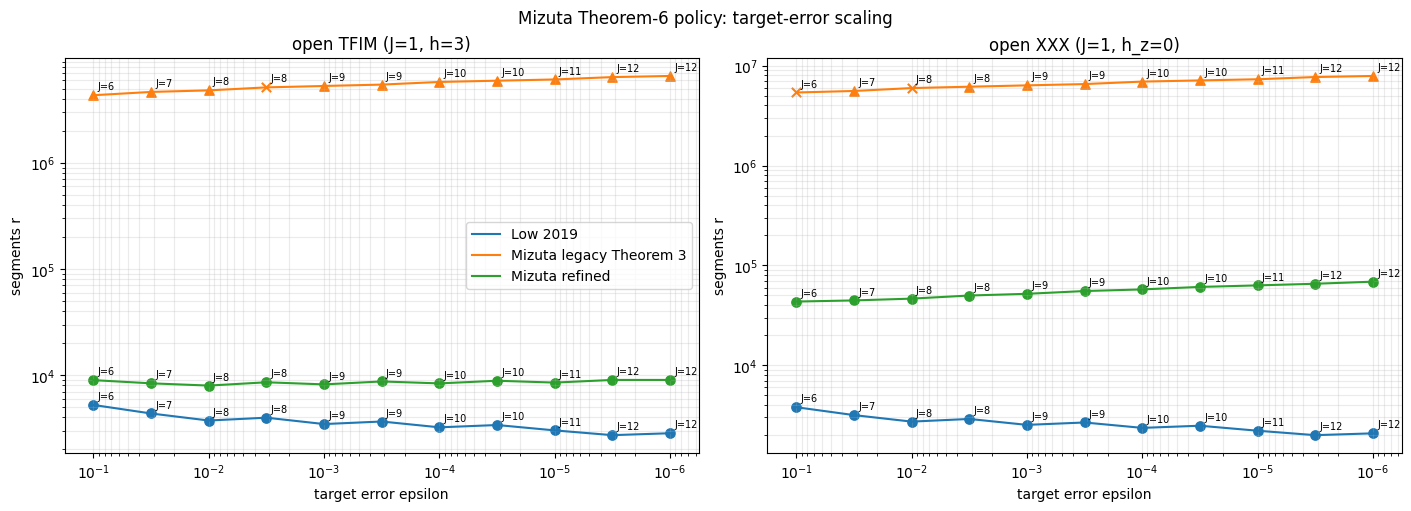

In [7]:
display(dynamic_targets[[
    'model', 'epsilon', 'estimator', 'J', 'formal_order', 'g', 'sum_k',
    'coefficient_l1', 'segments', 'p0', 'active_constraint',
    'local_error_dominance', 'legacy_first_pass', 'locality_fallback',
    'refined_tail_fallback', 'query_count',
]])
plot_segments(
    dynamic, sweep_name='target-error',
    title='Mizuta Theorem-6 policy: target-error scaling',
)

for frame in (fixed, dynamic):
    assert tuple(sorted(frame.loc[frame['sweep'].eq('system-size'), 'N'].unique())) == SIZES
    assert len(frame.loc[frame['sweep'].eq('target-error'), 'epsilon'].unique()) == 11
    assert set(frame['estimator']) == set(METHODS)
    assert (frame['segments'] >= 1).all()
    assert (frame['bound'] <= frame['epsilon']).all()
    assert (frame['query_count'] == 3 * frame['segments'] * frame['sum_k']).all()

for _, values in dynamic.groupby(['model', 'N', 'time', 'epsilon']):
    assert values['J'].nunique() == 1
    assert values['sum_k'].nunique() == 1
    assert values['coefficient_l1'].nunique() == 1
assert (dynamic.loc[dynamic['estimator'].eq('Mizuta refined'), 'p0'] >= 2 * dynamic.loc[
    dynamic['estimator'].eq('Mizuta refined'), 'J'
]).all()


## Interpretation

The fixed-order experiment isolates the error-proof comparison and shows the expected sixth-order target scaling. The policy experiment implements Theorem 6 deterministically rather than choosing a segment-minimizing order. Legacy rows expose the cost of the printed auxiliary BCH allocation and first time condition; refined rows expose and control the same BCH terms branchwise. The Hamiltonian, Suzuki formula, MPF cancellation equations, and physical circuit are unchanged.

The registered `new` and `legacy` schedule tables cover only $2\le J\le15$. A point resolving outside that interval is an explicit unsupported-order error rather than a clamped or nearby-order result.
